<a href="https://www.kaggle.com/code/chandunarisetti/gold-price-prediction?scriptVersionId=220983453" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/gold-price-dataset/gld_price_data.csv


# importing the libraries

In [2]:
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor

# Data collection and processing

In [3]:
# loading the csv data to a Pandas DataFrame
gold_data = pd.read_csv("/kaggle/input/gold-price-dataset/gld_price_data.csv")

In [4]:
# number of rows and columns
gold_data.shape

(2290, 6)

In [5]:
# print first 5 rows in the dataframe
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [6]:
# print last 5 rows of the dataframe
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [7]:
# getting some basic informations about the data
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [8]:
# checking the number of missing values
gold_data.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [9]:
# getting the statistical measures of the data
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


# check if any categorial data is present

In [10]:
#checking if any column has categorical data
categorical_data = gold_data.select_dtypes(include=['object', 'category']).columns
print(categorical_data)

Index(['Date'], dtype='object')


In [11]:
#removing the unnecessary data
gold_data=gold_data.drop(['Date'], axis=1)

In [12]:
#number of rows and columns after dropping unnecessary data
gold_data.shape

(2290, 5)

# finding the correaltion

### Correlation:
    1. Positive Correlation
    2. Negative Correlation

In [13]:
correlation = gold_data.corr()

In [14]:
print(correlation)

              SPX       GLD       USO       SLV   EUR/USD
SPX      1.000000  0.049345 -0.591573 -0.274055 -0.672017
GLD      0.049345  1.000000 -0.186360  0.866632 -0.024375
USO     -0.591573 -0.186360  1.000000  0.167547  0.829317
SLV     -0.274055  0.866632  0.167547  1.000000  0.321631
EUR/USD -0.672017 -0.024375  0.829317  0.321631  1.000000


<Axes: >

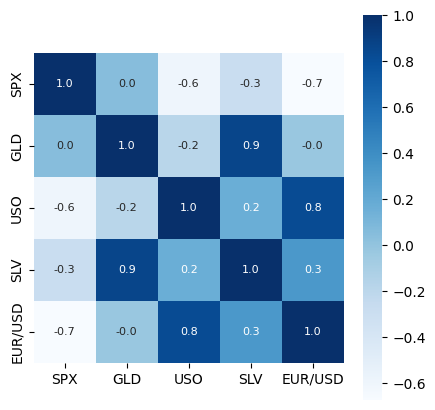

In [15]:
# constructing a heatmap to understand the correlation
plt.figure(figsize=(5,5))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

<ipython-input-16-40dd6dc4a289>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'], color='green')
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='GLD', ylabel='Density'>

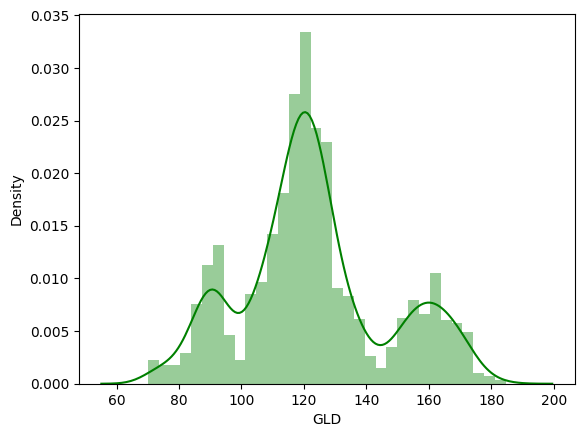

In [16]:
#checking the distribution of the gold prices
sns.distplot(gold_data['GLD'], color='green')

# splitting the features and target

In [17]:
x = gold_data.drop(['GLD'], axis = 1)
y = gold_data['GLD']

In [18]:
print(x.shape)
print(y.shape)

(2290, 4)
(2290,)


# splitting the training and test data

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state =2)

In [20]:
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(1603, 4) (687, 4) (1603,) (687,)


# Model Training: Random Forest Regressor

In [21]:
model = RandomForestRegressor(n_estimators=100)

In [22]:
model.fit(x_train, y_train)

RandomForestRegressor()

# model evalution

In [23]:
x_train_prediction = model.predict(x_train)

In [24]:
error_score = metrics.r2_score(y_train, x_train_prediction)
print("r squared error", error_score)

r squared error 0.998283741118544


In [25]:
x_test_prediction = model.predict(x_test)

In [26]:
print(x_test_prediction)

[168.75240006  82.08750014 116.0368003  127.50330113 120.65520182
 154.80469794 150.48400094 125.95120045 117.98059876 125.89410077
 116.27210116 172.68850081 142.31629962 167.78539856 115.11650018
 117.96140052 137.33530358 170.21570122 160.22050347 158.32709965
 155.14050012 125.75880001 175.69420007 156.71760274 125.05360083
  93.80359908  77.26919989 119.97389997 119.36980026 167.22440042
  88.48649888 125.3852014   90.93090062 117.71429978 121.20879936
 136.54830158 115.62130084 116.6471001  146.80949939 107.32750123
 104.21690174  87.35809795 126.57540067 117.39339938 153.62999909
 119.82530062 108.23500086 108.15989847  93.0915     127.33349675
  74.95490028 113.54219931 120.96559964 111.24649882 118.94289912
 121.01559976 158.06560095 163.75950165 146.71609663  86.74079978
  94.06219936  86.85939883  90.41300018 118.74390114 126.48580065
 127.80649961 168.89079937 122.06799954 117.44209927  98.93599937
 168.03080115 143.03749808 132.12740246 121.15180191 121.38479935
 119.68660

In [27]:
error_score = metrics.r2_score(y_test, x_test_prediction)
print("r squared error", error_score)

r squared error 0.9898497981994112


In [28]:
y_test = list(y_test)

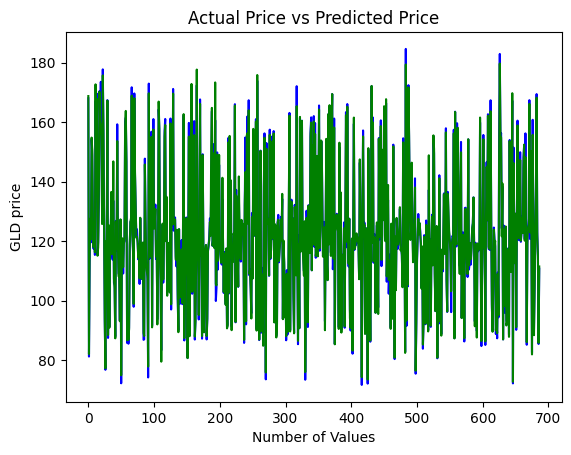

In [29]:
plt.plot(y_test, color='blue', label='Actual Values')
plt.plot(x_test_prediction, color='green', label='Predicted Values')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of Values')
plt.ylabel('GLD price')
plt.show()